# 01 - Correccion de senales sismicas

Caso USGS/PRISM: lectura SMC sin corregir, recomendacion automatica de parametros, ejecucion de la correccion recomendada y comparacion contra aceleracion, velocidad y desplazamiento corregidos por USGS.

In [26]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from signalprocessor.io import read_motion
from signalprocessor.metrics import (
    compute_ground_motion_parameters,
    compute_ground_motion_parameters_from_series,
    cumulative_arias,
    ground_motion_parameters_to_dict,
    integrate_motion,
)
from signalprocessor.recommendation import recommend_correction_method
from signalprocessor.spectra import response_spectrum


## Datos de entrada

Se usa un componente SMC sin corregir y los productos USGS corregidos correspondientes: aceleracion (`_a`), velocidad (`_v`) y desplazamiento (`_d`).

In [27]:
component = 'CCSP.HNN..'
raw_path = ROOT / f'examples/data/benchmark/uncorrected_motion/{component}_u.smc'
ref_acc_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_a.smc'
ref_vel_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_v.smc'
ref_disp_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_d.smc'

raw = read_motion(raw_path)
reference_acc = read_motion(ref_acc_path, units='cm/s^2')
reference_vel = read_motion(ref_vel_path, units='cm/s^2')  # canal numerico en cm/s
reference_disp = read_motion(ref_disp_path, units='cm/s^2')  # canal numerico en cm

pd.DataFrame([{
    'component': component,
    'npts': raw.npts,
    'dt_s': raw.dt,
    'duration_s': raw.duration,
    'units': raw.units,
}])


,component,npts,dt_s,duration_s,units
0,CCSP.HNN..,20200,0.01,201.99,cm/s^2


## Recomendacion automatica de parametros

El flujo automatizado sigue el marco teorico de correccion de senales:

1. Detecta ventanas por intensidad de Arias: pre-evento, fase fuerte y post-evento.
2. Evalua deriva cruda integrando aceleracion a velocidad y desplazamiento.
3. Detecta posibles spikes con una derivada robusta.
4. Estima cortes de filtro con relacion senal/ruido en Fourier cuando hay pre-evento suficiente.
5. Construye alternativas de baseline de bajo orden, sensibilidad de high-pass y controles de deriva de largo periodo usando solo las familias de filtro indicadas por el usuario.
6. Puntua cada alternativa por velocidad final, desplazamiento final normalizado por PGV, PGD/PGV, ondulacion post-evento, cambio espectral, PGA, Arias, CAV y complejidad.

`FILTER_TYPES_RECOMMENDATION` controla las familias evaluadas. Use `None`, `'all'` o `'todas'` para evaluar todas las disponibles; use una cadena o lista para limitar el barrido, por ejemplo `'bessel'`, `'cheby2'` o `['butterworth', 'bessel']`.


In [28]:
# Familias de filtro que entran al barrido automatico.
# Opciones canonicas: 'butterworth', 'cheby1', 'cheby2', 'ellip', 'bessel'.
# Tambien acepta alias: 'all'/'todas' para todas, 'chebyshev', 'chevyshev', 'elliptic', etc.
FILTER_TYPES_RECOMMENDATION = 'butterworth'
# Ejemplos:
# FILTER_TYPES_RECOMMENDATION = 'bessel'
# FILTER_TYPES_RECOMMENDATION = ['butterworth', 'bessel']

recommendation = recommend_correction_method(
    raw,
    t_min=0.01,
    t_max=3.0,
    snr_threshold=3.0,
    filter_types=FILTER_TYPES_RECOMMENDATION,
)
params = recommendation.parameter_suggestion
recommended = recommendation.best
result = recommended.result
project_acc = result.record.as_units('cm/s^2')

print('\n'.join(recommendation.decision_notes))
print('Notas de parametros:')
for note in params.notes:
    print(f'- {note}')

parameter_table = pd.DataFrame([params.to_row()]).T.rename(columns={0: 'valor_sugerido'})
parameter_table


Metodo recomendado: baseline_0_hp_0.1_postpoly_1_vf_df.
Familias de filtro consideradas: butterworth.
Los parametros se estimaron con ventanas Arias, SNR Fourier, drift terminal y sensibilidad de baseline/filtro.
La seleccion penaliza desplazamiento/velocidad de largo periodo no fisicos, deriva y tendencia post-evento sin distorsionar excesivamente PGA, Arias, CAV ni espectro.
Si el registro puede contener desplazamiento permanente fisico, revise manualmente candidatos con desplazamiento final impuesto.
Notas de parametros:
- Ventana pre-evento estimada: 10.873645819988228 s.
- Deriva cruda: velocidad final/PGV=1, desplazamiento final/PGD=1; severidad alta.
- Despiking activado; candidatos detectados=552.
- Familias de filtro evaluadas: butterworth.
- High-pass estimado por SNR: 0.0244 Hz.
- Low-pass estimado por SNR: 25 Hz.
- Se evaluan ordenes bajos de baseline, sensibilidad de high-pass y candidatos de control de deriva de largo periodo.


,valor_sugerido
pre_event_seconds,10.873646
baseline_orders,"1, 2, 0"
highpass_hz_candidates,"None, 0.02, 0.0244, 0.0391, 0.05, 0.08, 0.1"
lowpass_hz,25.0
taper_fraction,0.01
filter_order,4
filter_types,butterworth
despike,True
spike_sigma,8.0
constrain_final_velocity,True


In [29]:
window_table = pd.DataFrame([params.windows.to_row()]).T.rename(columns={0: 'segundos'})
window_table


,segundos
pre_event_seconds,10.873646
event_start_seconds,8.637483
strong_start_seconds,10.873646
strong_end_seconds,47.213168
post_event_start_seconds,92.853787
d5_95_seconds,71.880641


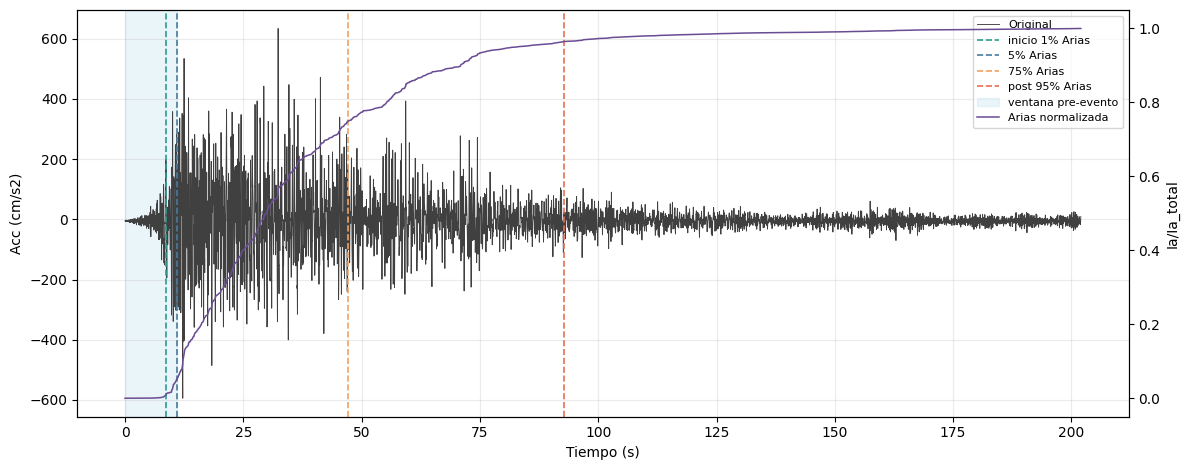

In [30]:
arias = cumulative_arias(raw.acceleration_si(), raw.dt)
fig, ax1 = plt.subplots(figsize=(12, 4.8))
ax1.plot(raw.time, raw.as_units('cm/s^2').acceleration, lw=0.65, color='0.25', label='Original')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Acc (cm/s2)')
ax1.grid(alpha=0.25)

for label, x, color in [
    ('inicio 1% Arias', params.windows.event_start_seconds, '#2a9d8f'),
    ('5% Arias', params.windows.strong_start_seconds, '#457b9d'),
    ('75% Arias', params.windows.strong_end_seconds, '#f4a261'),
    ('post 95% Arias', params.windows.post_event_start_seconds, '#e76f51'),
]:
    ax1.axvline(x, color=color, ls='--', lw=1.2, label=label)

if params.windows.pre_event_seconds is not None:
    ax1.axvspan(0.0, params.windows.pre_event_seconds, color='#8ecae6', alpha=0.18, label='ventana pre-evento')

ax2 = ax1.twinx()
ax2.plot(raw.time, arias / arias[-1], color='#6a4c93', lw=1.1, label='Arias normalizada')
ax2.set_ylabel('Ia/Ia_total')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=8)
fig.tight_layout()


## Ranking de alternativas evaluadas

El score menor es mejor. Las razones de velocidad son adimensionales; `final_displacement_pgv_seconds` y `pgd_pgv_seconds` estan en segundos y ayudan a detectar desplazamientos integrados no fisicos de muy largo periodo.


In [31]:
ranking = pd.DataFrame(recommendation.to_rows())
ranking_view = ranking[[
    'method',
    'score',
    'baseline_order',
    'highpass_hz',
    'lowpass_hz',
    'taper_fraction',
    'final_velocity_ratio',
    'final_displacement_ratio',
    'final_displacement_pgv_seconds',
    'pgd_pgv_seconds',
    'post_event_velocity_drift_ratio',
    'post_event_displacement_range_ratio',
    'spectral_rms_log_change',
    'pga_log_change',
    'arias_log_change',
    'cav_log_change',
]].head(12)
ranking_view


,method,score,baseline_order,highpass_hz,lowpass_hz,taper_fraction,final_velocity_ratio,final_displacement_ratio,final_displacement_pgv_seconds,pgd_pgv_seconds,post_event_velocity_drift_ratio,post_event_displacement_range_ratio,spectral_rms_log_change,pga_log_change,arias_log_change,cav_log_change
0,baseline_0_hp_0.1_postpoly_1_vf_df,0.754411,0,0.1000,25.0,0.01,5.463609e-15,2.095824e-12,5.963871e-13,0.284560,0.000097,0.456629,0.045436,0.016993,0.025167,0.021280
1,baseline_0_hp_0.0244_postpoly_1_vf_df,0.790910,0,0.0244,25.0,0.01,4.190258e-14,2.417036e-12,2.835675e-12,1.173203,0.012755,0.550432,0.045125,0.018321,0.024992,0.021336
2,baseline_0_hp_0.1,0.813662,0,0.1000,25.0,0.01,1.372206e-03,9.804960e-01,2.913099e-01,0.297105,0.000549,0.790318,0.045436,0.016994,0.025167,0.021280
3,baseline_0_hp_0.02_postpoly_1_vf_df,0.813663,0,0.0200,25.0,0.01,4.617247e-14,1.988672e-12,2.810858e-12,1.413435,0.008878,0.569746,0.045073,0.018303,0.024989,0.021347
4,baseline_1_hp_0.1,0.824585,1,0.1000,25.0,0.01,2.084954e-03,9.911190e-01,4.460802e-01,0.450077,0.000549,0.674915,0.045439,0.016994,0.025167,0.021278
5,baseline_1_hp_0.1_postpoly_1_vf_df,0.828118,1,0.1000,25.0,0.01,5.972392e-15,1.885740e-12,5.874916e-13,0.311544,0.001253,0.489415,0.045440,0.016996,0.025167,0.021278
6,baseline_2_hp_0.1_postpoly_1_vf_df,0.850804,2,0.1000,25.0,0.01,2.143610e-15,4.105463e-13,1.185883e-13,0.288855,0.000372,0.449358,0.045436,0.016993,0.025167,0.021279
7,baseline_2_hp_0.1,0.907920,2,0.1000,25.0,0.01,1.940923e-03,9.831087e-01,3.157910e-01,0.321217,0.000554,0.769985,0.045436,0.016994,0.025167,0.021279
8,baseline_0_hp_0.05_postpoly_1_vf_df,0.922599,0,0.0500,25.0,0.01,3.636867e-14,3.271733e-12,2.488919e-12,0.760734,0.015964,0.760905,0.045283,0.018310,0.025019,0.021278
9,baseline_1_hp_0.08_postpoly_1_vf_df,0.945486,1,0.0800,25.0,0.01,1.494325e-14,2.168517e-12,9.942103e-13,0.458475,0.000038,0.717324,0.045257,0.017845,0.025107,0.021259


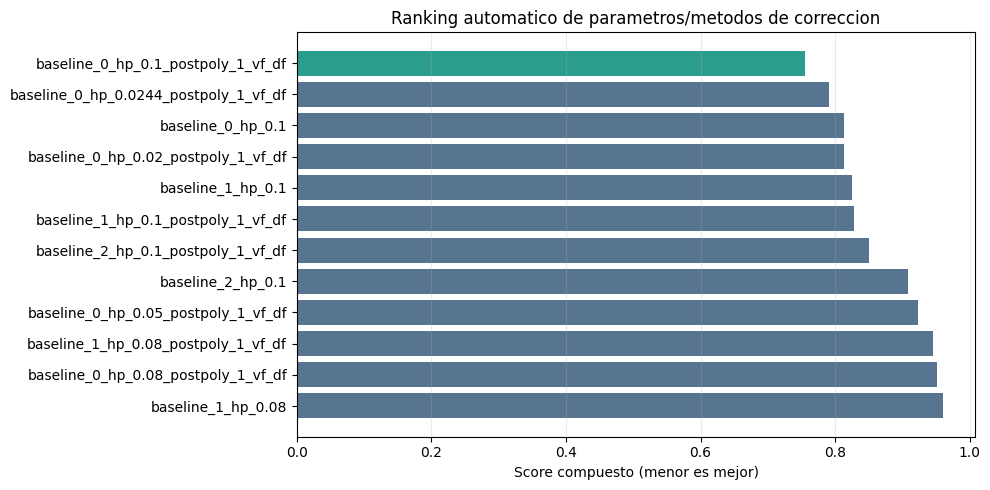

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
top = ranking.head(12).iloc[::-1]
colors = ['#2a9d8f' if method == recommended.name else '#577590' for method in top['method']]
ax.barh(top['method'], top['score'], color=colors)
ax.set_xlabel('Score compuesto (menor es mejor)')
ax.set_title('Ranking automatico de parametros/metodos de correccion')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()


## Comparacion con USGS

La senal del proyecto usa directamente la configuracion recomendada automaticamente. La tabla de resumen muestra las mismas unidades de los graficos: aceleracion en cm/s2, velocidad en cm/s y desplazamiento en cm.

Nota: los parametros del objeto `GroundMotionParameters` se almacenan internamente en SI. Para USGS se usan los canales publicados de velocidad (`_v`) y desplazamiento (`_d`) en vez de reintegrar solamente el canal de aceleracion (`_a`), porque esos productos ya incorporan su propia correccion de linea base.


In [33]:
raw_vel_mps, raw_disp_m = integrate_motion(raw.acceleration_si(), raw.dt)
project_vel_cms = result.velocity * 100.0
project_disp_cm = result.displacement * 100.0
raw_vel_cms = raw_vel_mps * 100.0
raw_disp_cm = raw_disp_m * 100.0
project_label = f'Proyecto auto ({recommended.name})'

# Metricas USGS desde los tres canales publicados: aceleracion, velocidad y desplazamiento.
# reference_vel.acceleration contiene numericamente cm/s y reference_disp.acceleration contiene cm.
n_ref = min(reference_acc.npts, reference_vel.npts, reference_disp.npts)
usgs_metrics = compute_ground_motion_parameters_from_series(
    reference_acc.time[:n_ref],
    reference_acc.acceleration_si()[:n_ref],
    velocity_si=reference_vel.acceleration[:n_ref] * 0.01,       # cm/s -> m/s
    displacement_si=reference_disp.acceleration[:n_ref] * 0.01, # cm -> m
)

summary = pd.DataFrame([
    ground_motion_parameters_to_dict(
        compute_ground_motion_parameters(raw),
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': 'original'},
    ground_motion_parameters_to_dict(
        result.metrics,
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': project_label},
    ground_motion_parameters_to_dict(
        usgs_metrics,
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': 'USGS canales publicados'},
]).set_index('stage')

summary[[
    'pga_cm_s2',
    'pgv_cm_s',
    'pgd_cm',
    'arias_intensity_m_s',
    'd5_95_s',
    'final_velocity_cm_s',
    'final_displacement_cm',
]]


,pga_cm_s2,pgv_cm_s,pgd_cm,arias_intensity_m_s,d5_95_s,final_velocity_cm_s,final_displacement_cm
stage,,,,,,,
original,634.160000,983.887637,93243.256062,17.408084,71.880641,-9.836970e+02,-9.324326e+04
Proyecto auto (baseline_0_hp_0.1_postpoly_1_vf_df),645.028315,37.161846,10.574766,16.975438,70.599808,-2.030378e-13,-2.216285e-11
USGS canales publicados,638.320000,38.087000,20.069000,17.329166,69.697811,-2.879100e-02,-5.730300e-01


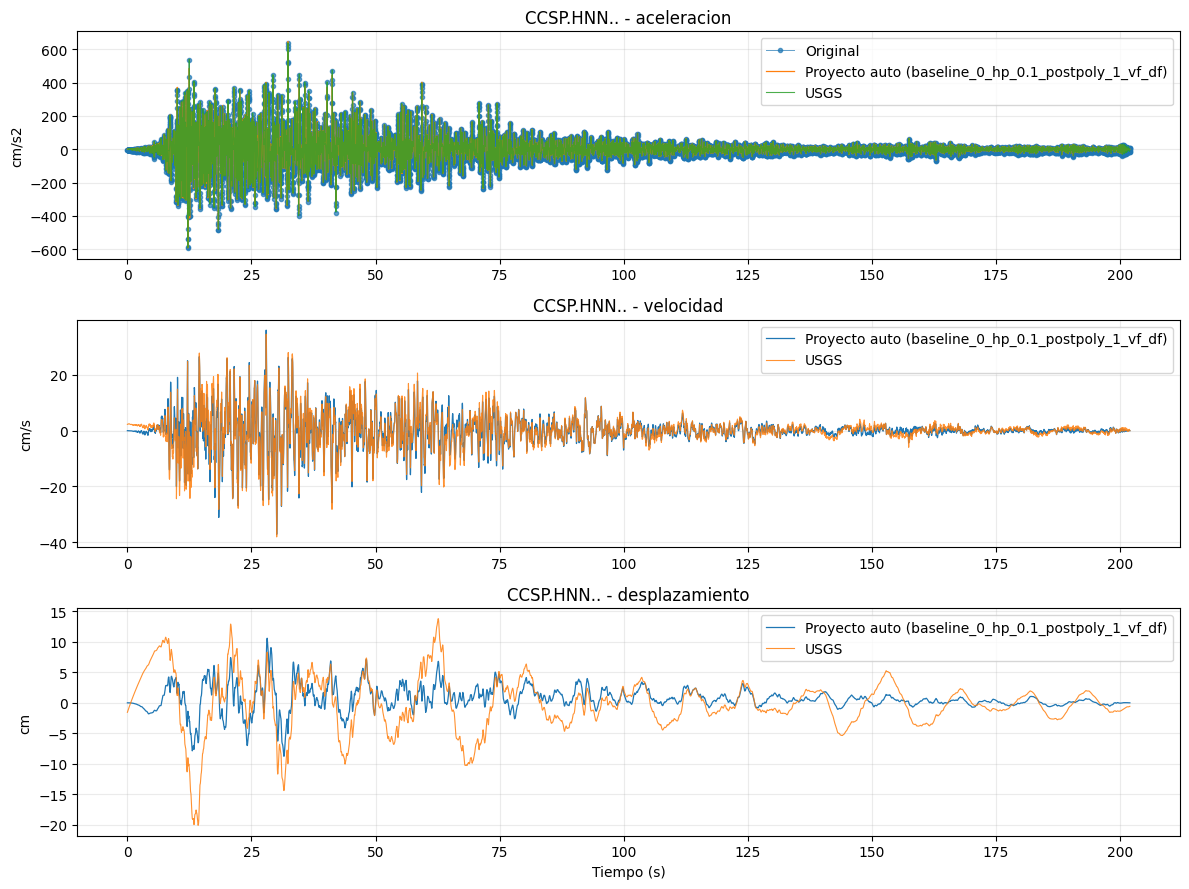

In [34]:
n_acc = min(raw.npts, project_acc.npts, reference_acc.npts)
n_vel = min(raw.npts, result.velocity.size, reference_vel.npts)
n_disp = min(raw.npts, result.displacement.size, reference_disp.npts)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

axes[0].plot(raw.time[:n_acc], raw.as_units('cm/s^2').acceleration[:n_acc], lw=0.7, alpha=0.7, label='Original', marker='o', markersize=3)
axes[0].plot(project_acc.time[:n_acc], project_acc.acceleration[:n_acc], lw=0.9, label=project_label)
axes[0].plot(reference_acc.time[:n_acc], reference_acc.acceleration[:n_acc], lw=0.8, alpha=0.85, label='USGS')
axes[0].set_title(f'{component} - aceleracion')
axes[0].set_ylabel('cm/s2')

# axes[1].plot(raw.time[:n_vel], raw_vel_cms[:n_vel], lw=0.7, alpha=0.7, label='Original integrada')
axes[1].plot(result.record.time[:n_vel], project_vel_cms[:n_vel], lw=0.9, label=project_label)
axes[1].plot(reference_vel.time[:n_vel], reference_vel.acceleration[:n_vel], lw=0.8, alpha=0.85, label='USGS')
axes[1].set_title(f'{component} - velocidad')
axes[1].set_ylabel('cm/s')

# axes[2].plot(raw.time[:n_disp], raw_disp_cm[:n_disp], lw=0.7, alpha=0.7, label='Original integrada')
axes[2].plot(result.record.time[:n_disp], project_disp_cm[:n_disp], lw=0.9, label=project_label)
axes[2].plot(reference_disp.time[:n_disp], reference_disp.acceleration[:n_disp], lw=0.8, alpha=0.85, label='USGS')
axes[2].set_title(f'{component} - desplazamiento')
axes[2].set_ylabel('cm')
axes[2].set_xlabel('Tiempo (s)')

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()


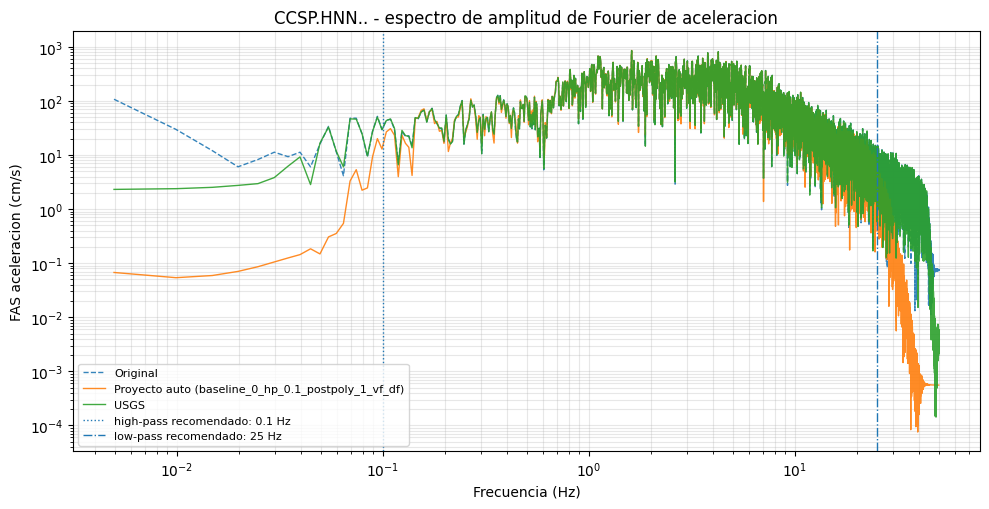

In [35]:
from signalprocessor.spectra import fourier_amplitude_spectrum


def _fas_acc_cm_s(record):
    freqs, amp_m_s = fourier_amplitude_spectrum(record)
    return freqs, amp_m_s * 100.0  # m/s -> cm/s; FAS de aceleracion = (cm/s2) * s


fas_series = [
    (_fas_acc_cm_s(raw), 'Original', '--'),
    (_fas_acc_cm_s(project_acc), project_label, '-'),
    (_fas_acc_cm_s(reference_acc), 'USGS', '-'),
]

fig, ax = plt.subplots(figsize=(10, 5.2))
for (freqs, amp), label, linestyle in fas_series:
    mask = (freqs > 0.0) & np.isfinite(amp) & (amp > 0.0)
    ax.loglog(freqs[mask], amp[mask], linestyle=linestyle, lw=1.0, alpha=0.9, label=label)

for cutoff_label, cutoff_hz, linestyle in [
    ('high-pass recomendado', recommended.config.highpass_hz, ':'),
    ('low-pass recomendado', recommended.config.lowpass_hz, '-.'),
]:
    if cutoff_hz is not None and cutoff_hz > 0.0:
        ax.axvline(cutoff_hz, linestyle=linestyle, lw=1.0, label=f'{cutoff_label}: {cutoff_hz:g} Hz')

ax.set_title(f'{component} - espectro de amplitud de Fourier de aceleracion')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('FAS aceleracion (cm/s)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()



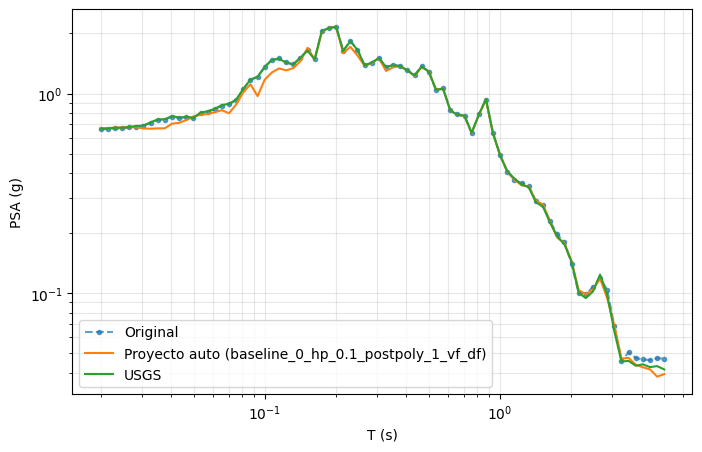

In [36]:
periods = np.geomspace(0.02, 5.0, 80)
spec_raw = response_spectrum(raw, periods)
spec_project = response_spectrum(project_acc, periods)
spec_usgs = response_spectrum(reference_acc, periods)

plt.figure(figsize=(8, 5))
plt.loglog(spec_raw.periods, spec_raw.sa, '--', alpha=0.7, label='Original', marker='o', markersize=3)
plt.loglog(spec_project.periods, spec_project.sa, label=project_label)
plt.loglog(spec_usgs.periods, spec_usgs.sa, label='USGS')
plt.xlabel('T (s)')
plt.ylabel('PSA (g)')
plt.grid(True, which='both', alpha=0.3)
plt.legend();
